In [1]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image


In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


In [3]:
## Get the projected latitude and longitude 

h_target = 110000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_110_proj, yknf_lon_110_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_110_proj, fsmi_lon_110_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


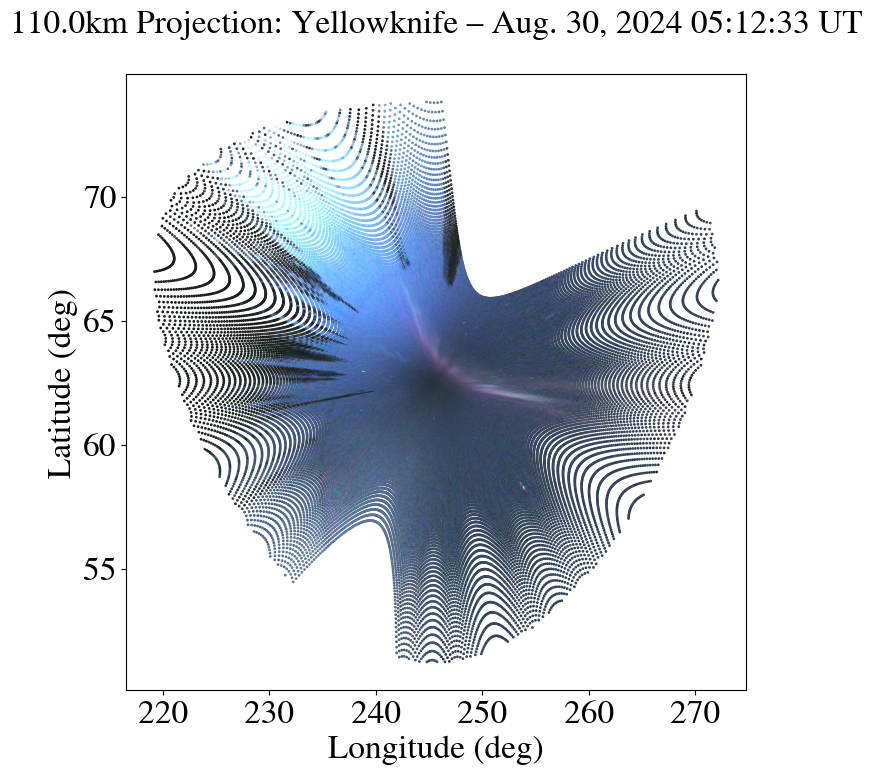

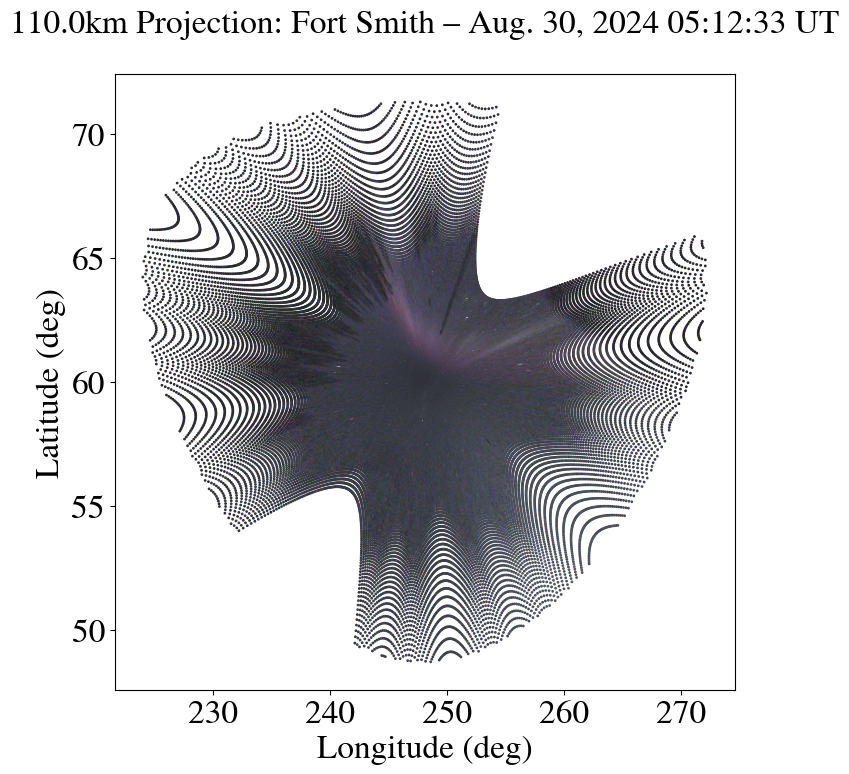

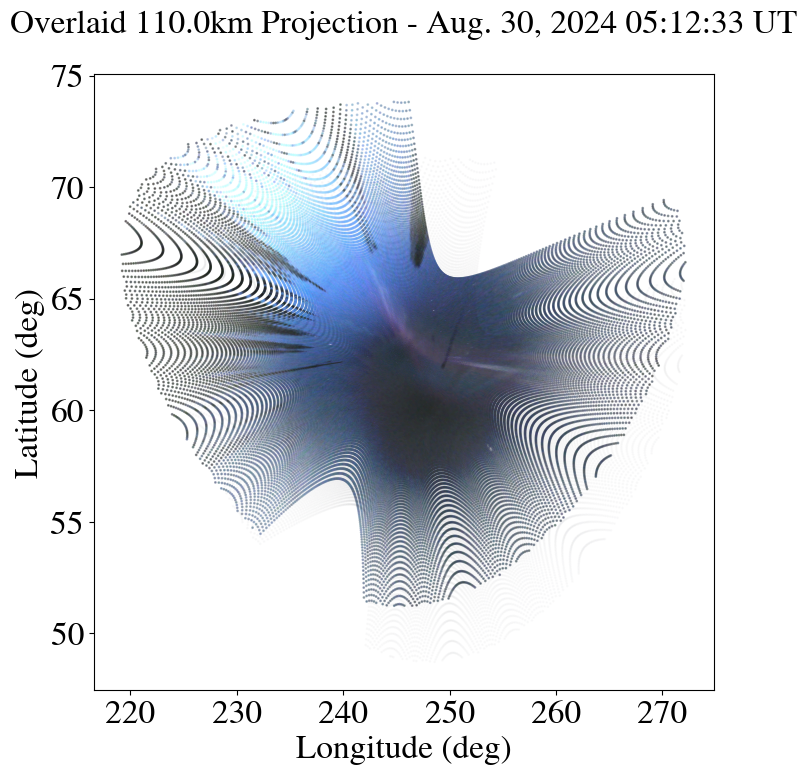

In [4]:
## Plot the projected latitude and longitude

time_index = 251 # 5:10 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_110_proj, 
                                 yknf_lon_110_proj, 
                                 fsmi_lat_110_proj, 
                                 fsmi_lon_110_proj,
                                 h_target)

## Interpolation (Linear)
1. define a common grid over which to perform the interpolation --> this common grid is based on the maximum and minimum latitude/longitude BEFORE masking
- get the overlapping area
3. interpolate the pixel intensities from both cameras over this entire grid
4. manually cut out the area with the auroral pixels (create some custom mask for a particular altitude, then repeat for many altitudes to get a correlation plot over different projected altitudes)

DON'T DO MASKING --> want to independently pick out some of the 

In [5]:
yknf_rgb.shape

(480, 553, 3)

In [6]:
yknf_lat_110_proj.shape

(480, 553)

In [9]:
def rgb_interpolate(lat_proj, lon_proj, rgb, 
                    grid_x, grid_y,
                   lat_min, lat_max, lon_min, lon_max):
    """
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of plot_lat_lon()) 
        n_lat = how many x-values for interpolated grid
        n_lon = how many y-values for interpolated grid 
        lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
        lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
        lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
        lon_max = maximum longitude to create grid for (should be common between the 2 cameras)

    output:
        interp_intensity_R = 2D arr (grid_x, grid_y) of interpolated R-channel 
        interp_intensity_G = 2D arr (grid_x, grid_y) of interpolated G-channel 
        interp_intensity_B = 2D arr (grid_x, grid_y) of interpolated B-channel 
    """
    # grid --> need to make this more sophisticated, bc some distortion from using the dims of az/el grid
    lat_grid = np.linspace(lat_min, lat_max, n_lat)
    lon_grid = np.linspace(lon_min, lon_max, n_lon)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    
    # separate into R, G, B channels
    R = rgb[:,:, 0]
    G = rgb[:,:, 1]
    B = rgb[:,:, 2]

    # flatten yknf and fsmi projected arrays + R + G + B arrays 
    flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
    flattened_R = R.flatten()
    flattened_G = G.flatten()
    flattened_B = B.flatten()
    

    # remove NaNs
    # masks for NaNs in R, G, and B channels separately 
    nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
    nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
    nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))
    
    points_R_clean = flattened_points[nan_mask_R]
    points_G_clean = flattened_points[nan_mask_G]
    points_B_clean = flattened_points[nan_mask_B]
    
    values_R_clean = flattened_R[nan_mask_R]
    values_G_clean = flattened_G[nan_mask_G]
    values_B_clean = flattened_B[nan_mask_B]
    
    
    # interpolation 
    interp_intensity_R = griddata(points_R_clean, values_R_clean, (lon_mesh, lat_mesh), method='linear')
    interp_intensity_G = griddata(points_G_clean, values_G_clean, (lon_mesh, lat_mesh), method='linear')
    interp_intensity_B = griddata(points_B_clean, values_B_clean, (lon_mesh, lat_mesh), method='linear')

    return interp_intensity_R, interp_intensity_G, interp_intensity_B

    
    

In [10]:
lat_min = max(np.nanmin(yknf_lat_110_proj), np.nanmin(fsmi_lat_110_proj))
lon_min = max(np.nanmin(yknf_lon_110_proj), np.nanmin(fsmi_lon_110_proj))
lat_max = min(np.nanmax(yknf_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
lon_max = min(np.nanmax(yknf_lon_110_proj), np.nanmax(fsmi_lon_110_proj))

n_lat = 500
n_lon = 500

yknf_interp_intensity_R, yknf_interp_intensity_G, yknf_interp_intensity_B = rgb_interpolate(yknf_lat_110_proj, yknf_lon_110_proj, yknf_rgb, 
                                                                                            n_lat, n_lon,
                                                                                            lat_min, lat_max, lon_min, lon_max)

fsmi_interp_intensity_R, fsmi_interp_intensity_G, fsmi_interp_intensity_B = rgb_interpolate(fsmi_lat_110_proj, fsmi_lon_110_proj, fsmi_rgb, 
                                                                                            n_lat, n_lon,
                                                                                            lat_min, lat_max, lon_min, lon_max)


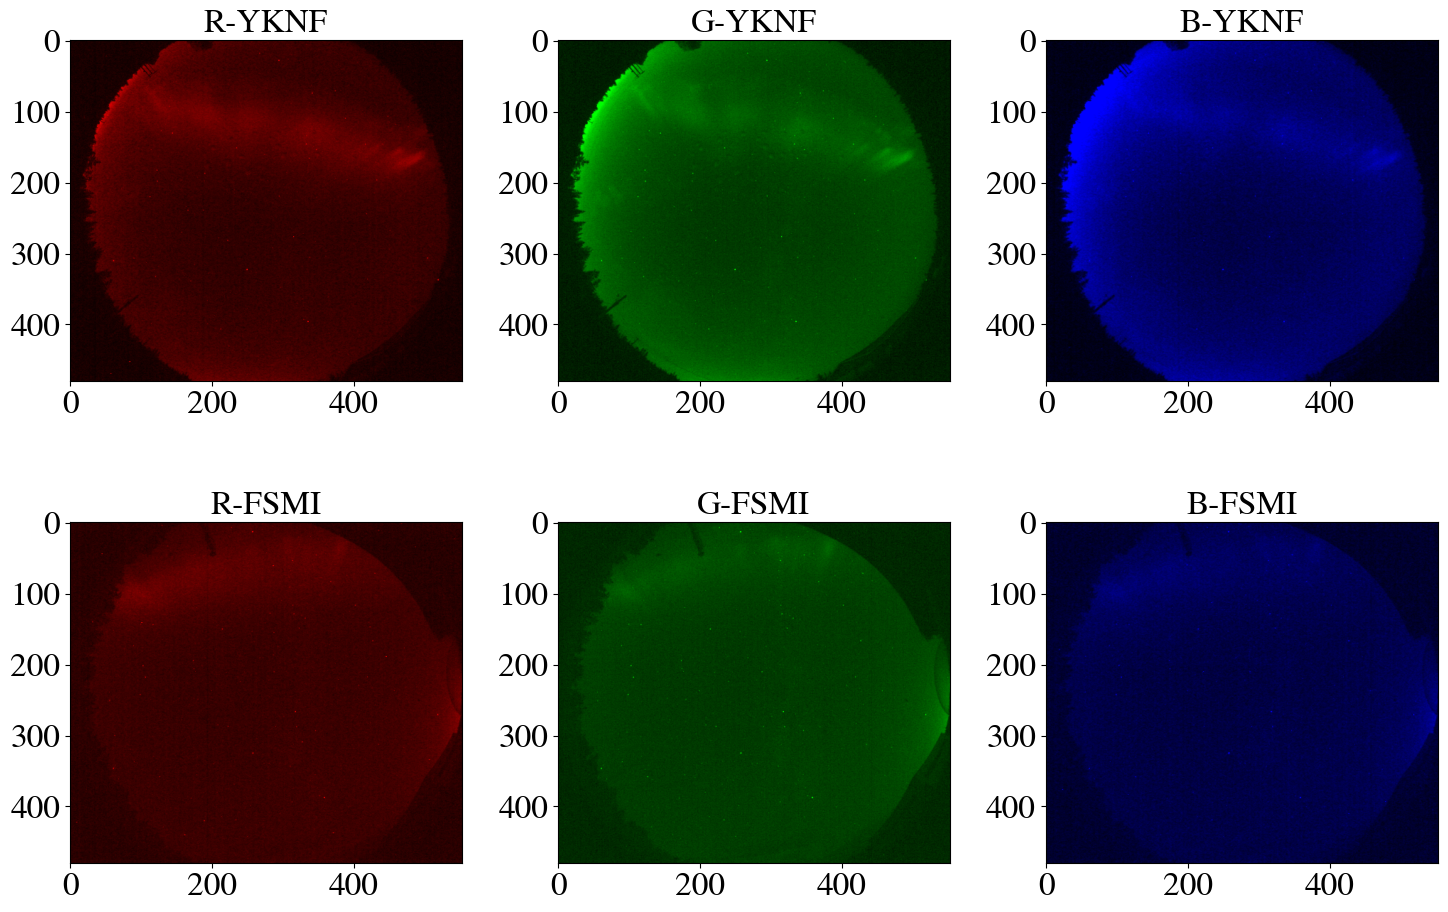

In [18]:
## YKNF vs FSMI: Plot original camera separate R, G, B channels 

R_yknf = yknf_rgb[:,:, 0]
G_yknf = yknf_rgb[:,:, 1]
B_yknf = yknf_rgb[:,:, 2]

R_fsmi = fsmi_rgb[:,:, 0]
G_fsmi = fsmi_rgb[:,:, 1]
B_fsmi = fsmi_rgb[:,:, 2]

R_color_yknf = np.dstack((R_yknf / 255.0, np.zeros_like(R_yknf), np.zeros_like(R_yknf))) 
G_color_yknf = np.dstack((np.zeros_like(G_yknf), G_yknf / 255.0, np.zeros_like(G_yknf)))
B_color_yknf = np.dstack((np.zeros_like(B_yknf), np.zeros_like(B_yknf), B_yknf / 255.0))

R_color_fsmi = np.dstack((R_fsmi / 255.0, np.zeros_like(R_fsmi), np.zeros_like(R_fsmi))) 
G_color_fsmi = np.dstack((np.zeros_like(G_fsmi), G_fsmi / 255.0, np.zeros_like(G_fsmi)))
B_color_fsmi = np.dstack((np.zeros_like(B_fsmi), np.zeros_like(B_fsmi), B_fsmi / 255.0))


fig, axes = plt.subplots(2, 3, figsize=(15,10))
all_images = [R_color_yknf, G_color_yknf, B_color_yknf, R_color_fsmi, G_color_fsmi, B_color_fsmi]
all_titles = ['R-YKNF', 'G-YKNF', 'B-YKNF', 'R-FSMI', 'G-FSMI', 'B-FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title)
    
plt.tight_layout()
plt.show()

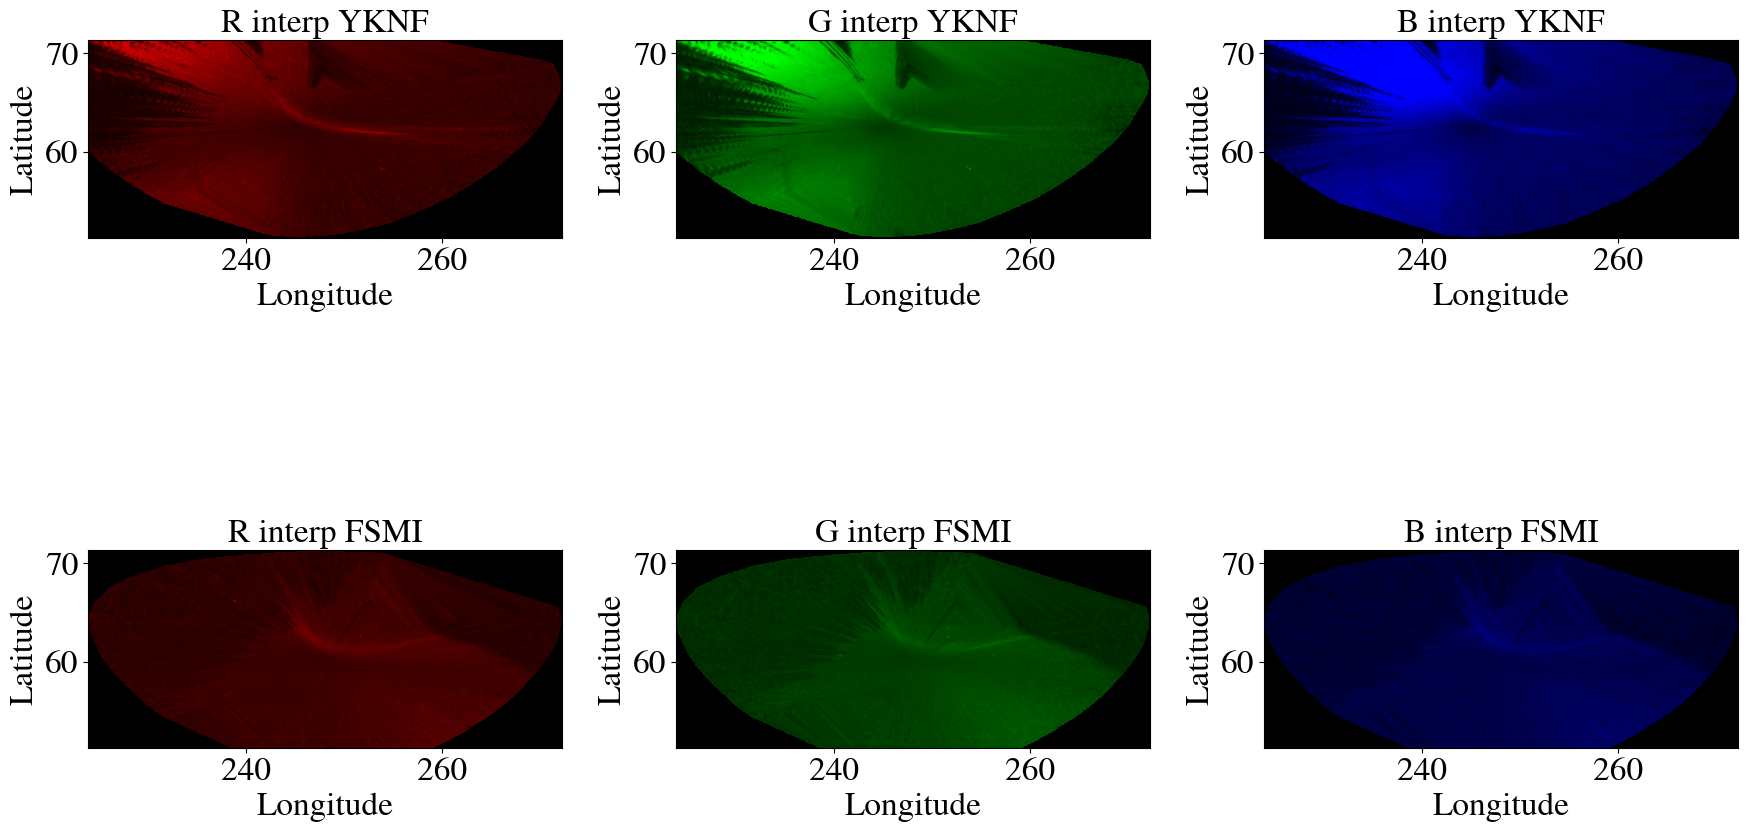

In [21]:
## YKNF vs FSMI: Plot interpolated R, G, B channels

yknf_R_interp_color = np.dstack((yknf_interp_intensity_R / 255.0, np.zeros_like(yknf_interp_intensity_R), np.zeros_like(yknf_interp_intensity_R))) 
yknf_G_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_G), yknf_interp_intensity_G / 255.0, np.zeros_like(yknf_interp_intensity_G)))
yknf_B_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_B), np.zeros_like(yknf_interp_intensity_B), yknf_interp_intensity_B / 255.0))

fsmi_R_interp_color = np.dstack((fsmi_interp_intensity_R / 255.0, np.zeros_like(fsmi_interp_intensity_R), np.zeros_like(fsmi_interp_intensity_R))) 
fsmi_G_interp_color = np.dstack((np.zeros_like(fsmi_interp_intensity_G), fsmi_interp_intensity_G / 255.0, np.zeros_like(fsmi_interp_intensity_G)))
fsmi_B_interp_color = np.dstack((np.zeros_like(fsmi_interp_intensity_B), np.zeros_like(fsmi_interp_intensity_B), fsmi_interp_intensity_B / 255.0))


fig, axes = plt.subplots(2, 3, figsize=(18,12))
all_images = [yknf_R_interp_color, yknf_G_interp_color, yknf_B_interp_color, fsmi_R_interp_color, fsmi_G_interp_color, fsmi_B_interp_color]
all_titles = ['R interp YKNF', 'G interp YKNF', 'B interp YKNF', 'R interp FSMI', 'G interp FSMI', 'B interp FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max])  # clip to stay in valid display range
    ax.set_title(title)
    ax.set_aspect('equal')  # keeps proportions
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

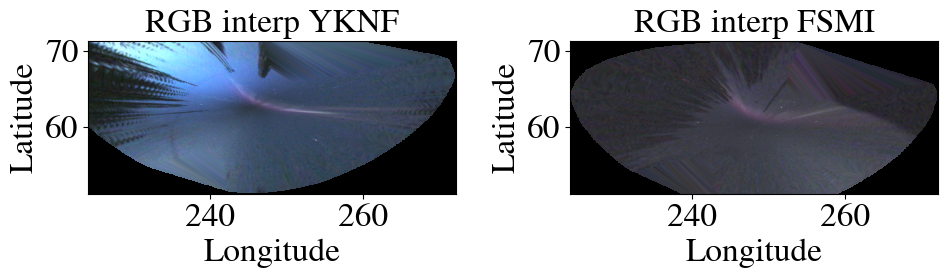

In [25]:
## YKNF vs FSMI: Plot interpolated stacked RGB

yknf_rgb_image = np.dstack((yknf_interp_intensity_R/255.0, yknf_interp_intensity_G/255.0, yknf_interp_intensity_B/255.0))
fsmi_rgb_image = np.dstack((fsmi_interp_intensity_R/255.0, fsmi_interp_intensity_G/255.0, fsmi_interp_intensity_B/255.0))


fig, axes = plt.subplots(1, 2, figsize=(10,20))
all_images = [yknf_rgb_image, fsmi_rgb_image]
all_titles = ['RGB interp YKNF', 'RGB interp FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max]) 
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


In [16]:
# interpolate over the entire grid first
lat_min = max(np.nanmin(yknf_lat_110_proj), np.nanmin(fsmi_lat_110_proj))
lon_min = max(np.nanmin(yknf_lon_110_proj), np.nanmin(fsmi_lon_110_proj))
lat_max = min(np.nanmax(yknf_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
lon_max = min(np.nanmax(yknf_lon_110_proj), np.nanmax(fsmi_lon_110_proj))

# grid --> need to make this more sophisticated, bc some distortion from using the dims of az/el grid
n_lat = 500
n_lon = 500
lat_grid = np.linspace(lat_min, lat_max, n_lat)
lon_grid = np.linspace(lon_min, lon_max, n_lon)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# separate into R, G, B channels
R_yknf = yknf_rgb[:,:, 0]
G_yknf = yknf_rgb[:,:, 1]
B_yknf = yknf_rgb[:,:, 2]

R_fsmi = fsmi_rgb[:,:, 0]
G_fsmi = fsmi_rgb[:,:, 1]
B_fsmi = fsmi_rgb[:,:, 2]


# flatten yknf and fsmi projected arrays + R + G + B arrays 
yknf_flattened_points = np.column_stack((yknf_lon_110_proj.flatten(), yknf_lat_110_proj.flatten())) # (N,2) pairs of (lat, lon)
yknf_flattened_R = R_yknf.flatten()
yknf_flattened_G = G_yknf.flatten()
yknf_flattened_B = B_yknf.flatten()

fsmi_flattened_points = np.column_stack((fsmi_lon_110_proj.flatten(), fsmi_lat_110_proj.flatten()))
fsmi_flattened_R = R_fsmi.flatten()
fsmi_flattened_G = G_fsmi.flatten()
fsmi_flattened_B = B_fsmi.flatten()


# remove NaNs
# masks for NaNs in R, G, and B channels separately 
yknf_nan_mask_R = (np.isfinite(yknf_flattened_points[:,0]) & np.isfinite(yknf_flattened_points[:,1]) & np.isfinite(yknf_flattened_R))
yknf_nan_mask_G = (np.isfinite(yknf_flattened_points[:,0]) & np.isfinite(yknf_flattened_points[:,1]) & np.isfinite(yknf_flattened_G))
yknf_nan_mask_B = (np.isfinite(yknf_flattened_points[:,0]) & np.isfinite(yknf_flattened_points[:,1]) & np.isfinite(yknf_flattened_B))

fsmi_nan_mask_R = (np.isfinite(fsmi_flattened_points[:,0]) & np.isfinite(fsmi_flattened_points[:,1]) & np.isfinite(fsmi_flattened_R))
fsmi_nan_mask_G = (np.isfinite(fsmi_flattened_points[:,0]) & np.isfinite(fsmi_flattened_points[:,1]) & np.isfinite(fsmi_flattened_G))
fsmi_nan_mask_B = (np.isfinite(fsmi_flattened_points[:,0]) & np.isfinite(fsmi_flattened_points[:,1]) & np.isfinite(fsmi_flattened_B))

yknf_points_R_clean = yknf_flattened_points[yknf_nan_mask_R]
yknf_points_G_clean = yknf_flattened_points[yknf_nan_mask_G]
yknf_points_B_clean = yknf_flattened_points[yknf_nan_mask_B]

yknf_values_R_clean = yknf_flattened_R[yknf_nan_mask_R]
yknf_values_G_clean = yknf_flattened_G[yknf_nan_mask_G]
yknf_values_B_clean = yknf_flattened_B[yknf_nan_mask_B]

fsmi_points_R_clean = fsmi_flattened_points[fsmi_nan_mask_R]
fsmi_points_G_clean = fsmi_flattened_points[fsmi_nan_mask_G]
fsmi_points_B_clean = fsmi_flattened_points[fsmi_nan_mask_B]

fsmi_values_R_clean = fsmi_flattened_R[fsmi_nan_mask_R]
fsmi_values_G_clean = fsmi_flattened_G[fsmi_nan_mask_G]
fsmi_values_B_clean = fsmi_flattened_B[fsmi_nan_mask_B]


# interpolation 
yknf_interp_intensity_R = griddata(yknf_points_R_clean, yknf_values_R_clean, (lon_mesh, lat_mesh), method='linear')
yknf_interp_intensity_G = griddata(yknf_points_G_clean, yknf_values_G_clean, (lon_mesh, lat_mesh), method='linear')
yknf_interp_intensity_B = griddata(yknf_points_B_clean, yknf_values_B_clean, (lon_mesh, lat_mesh), method='linear')

fsmi_interp_intensity_R = griddata(fsmi_points_R_clean, fsmi_values_R_clean, (lon_mesh, lat_mesh), method='linear')
fsmi_interp_intensity_G = griddata(fsmi_points_G_clean, fsmi_values_G_clean, (lon_mesh, lat_mesh), method='linear')
fsmi_interp_intensity_B = griddata(fsmi_points_B_clean, fsmi_values_B_clean, (lon_mesh, lat_mesh), method='linear')


# # get only auroras
# yknf_interp_aurora = np.where(yknf_aurora_mask, yknf_interp_intensity, np.nan)
# fsmi_interp_aurora = np.where(fsmi_aurora_mask, fsmi_interp_intensity, np.nan)

# yknf_interp_aurora_flat = yknf_interp_aurora.flatten()
# fsmi_interp_aurora_flat = fsmi_interp_aurora.flatten()

# masking
# yknf_final_mask, yknf_aurora = masking(yknf_interp_intensity)
# fsmi_final_mask, fsmi_aurora = masking(fsmi_interp_intensity)


# remove NaNs
# valid = ~np.isnan(yknf_aurora) & ~np.isnan(fsmi_aurora)
# yknf_interp_valid = yknf_aurora[valid]
# fsmi_interp_valid = fsmi_aurora[valid]

# yknf_interp_intensity = yknf_interp_intensity[valid]
# fsmi_interp_intensity = fsmi_interp_intensity[valid]


# corr, _ = pearsonr(yknf_interp_intensity, fsmi_interp_intensity)
# print("YKNF and FSMI intensity correlation before masking:", corr)


In [65]:
yknf_interp_intensity_R.shape

(500, 500)

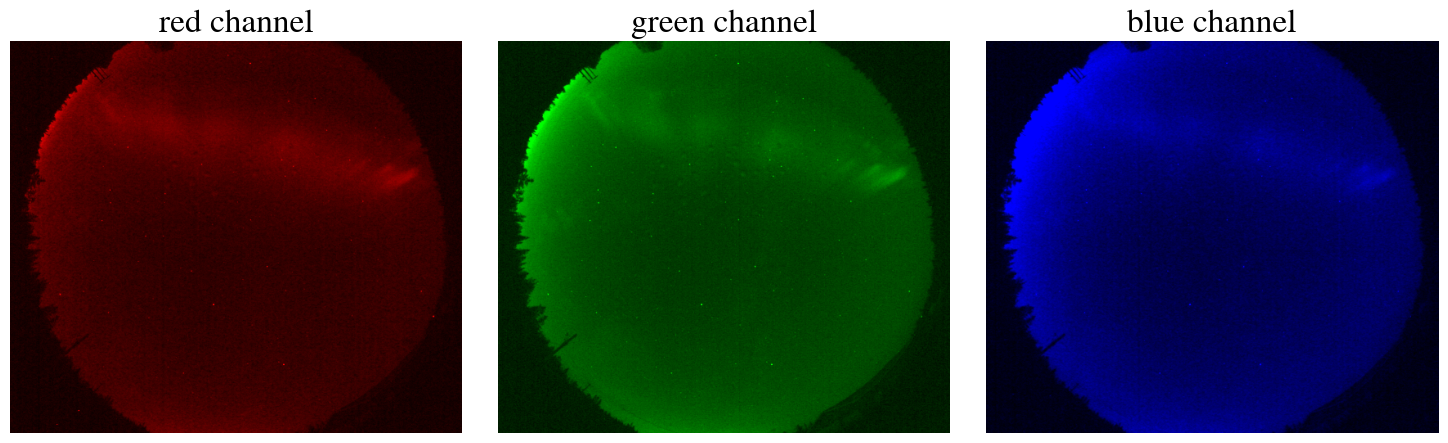

In [29]:
R_color = np.dstack((R_yknf / 255.0, np.zeros_like(R_yknf), np.zeros_like(R_yknf))) 
G_color = np.dstack((np.zeros_like(G_yknf), G_yknf / 255.0, np.zeros_like(G_yknf)))
B_color = np.dstack((np.zeros_like(B_yknf), np.zeros_like(B_yknf), B_yknf / 255.0))

fig, axes = plt.subplots(1, 3, figsize=(15,5))
titles = ['red channel', 'green channel', 'blue channel']

for ax, img, title in zip(axes, [R_color, G_color, B_color], titles):
    ax.imshow(np.clip(img, 0, 1))  # clip to stay in valid display range
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

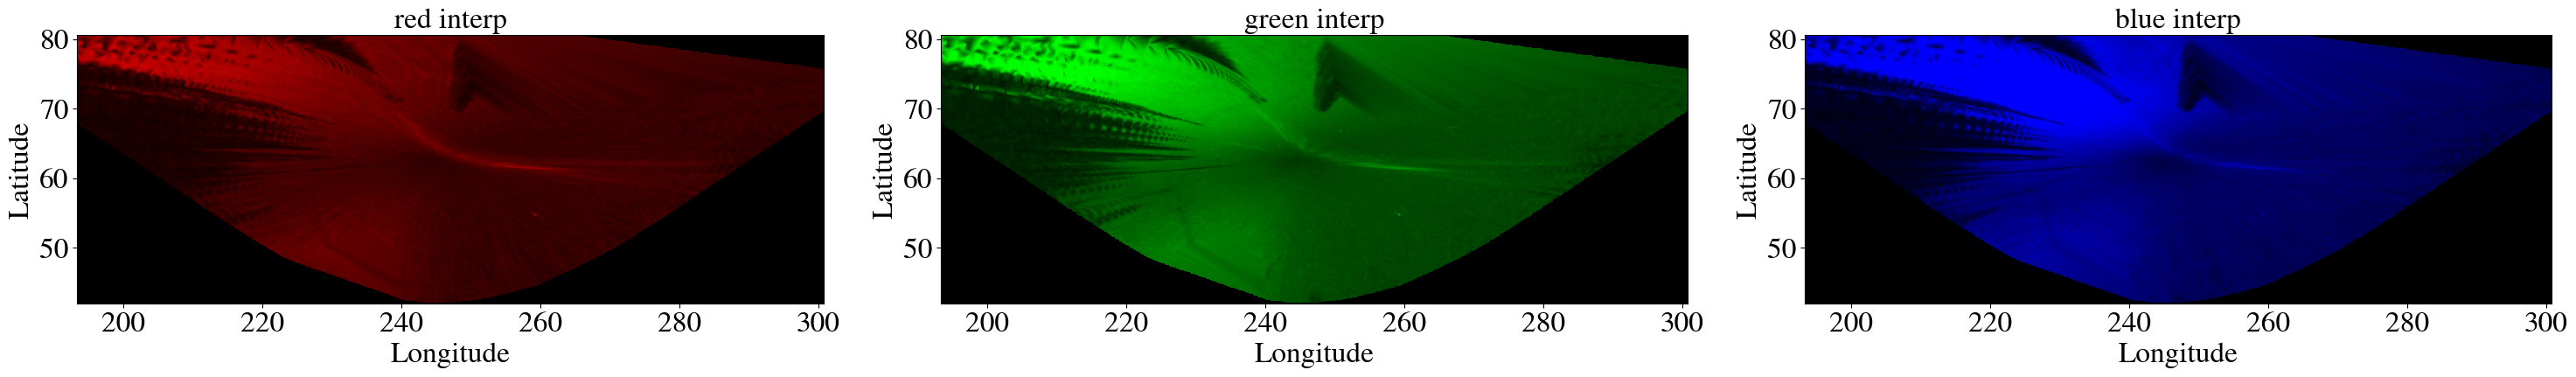

In [56]:
R_interp_color = np.dstack((yknf_interp_intensity_R / 255.0, np.zeros_like(yknf_interp_intensity_R), np.zeros_like(yknf_interp_intensity_R))) 
G_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_G), yknf_interp_intensity_G / 255.0, np.zeros_like(yknf_interp_intensity_G)))
B_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_B), np.zeros_like(yknf_interp_intensity_B), yknf_interp_intensity_B / 255.0))

fig, axes = plt.subplots(1, 3, figsize=(30,10))
titles = ['red interp', 'green interp', 'blue interp']

for ax, img, title in zip(axes, [R_interp_color, G_interp_color, B_interp_color], titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max])  # clip to stay in valid display range
    ax.set_title(title)
    ax.set_aspect('equal')  # keeps proportions
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

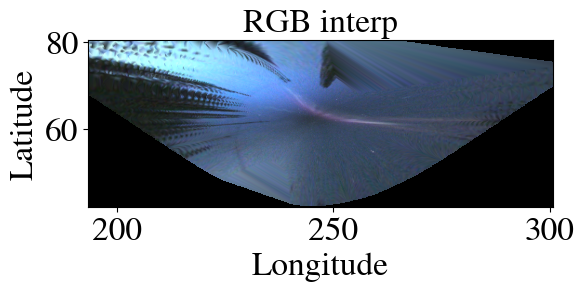

In [59]:
rgb_image = np.dstack((yknf_interp_intensity_R/255.0, yknf_interp_intensity_G/255.0, yknf_interp_intensity_B/255.0))
plt.figure(figsize=(6,6))
plt.imshow(np.clip(rgb_image, 0, 1),
          origin='lower',
          extent=[lon_min, lon_max, lat_min, lat_max]) 
plt.title("RGB interp")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [52]:
# independent cutoff


In [ ]:
# correlation after strict line cutoff 
valid = ~np.isnan(yknf_line_masked_intensity) & ~np.isnan(fsmi_aurora)
yknf_interp_line_valid = yknf_line_masked_intensity[valid]
fsmi_interp_line_valid = fsmi_aurora[valid]

corr_line, _ = pearsonr(yknf_interp_line_valid, fsmi_interp_line_valid)
print("YKNF and FSMI intensity correlation after line cutoff:", corr_line)


In [ ]:
# after strict cutoff 
plt.figure(figsize=(6,6))
plt.imshow(yknf_total_mask, alpha=0.5, cmap='Reds', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.imshow(fsmi_final_mask, alpha=0.5, cmap='Blues', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("Auroral overlap: Red=YKNF, Blue=FSMI")
plt.show()

In [ ]:
vmin = min(np.nanmin(yknf_interp_intensity), np.nanmin(fsmi_interp_intensity))
vmax = max(np.nanmax(yknf_interp_intensity), np.nanmax(fsmi_interp_intensity))

plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.imshow(yknf_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("YKNF interpolated")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(fsmi_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("FSMI interpolated")
plt.colorbar()


In [ ]:
print(lat_min, lat_max, lon_min, lon_max)

In [ ]:
plt.scatter(yknf_points_clean[:,0], yknf_points_clean[:,1], s=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("YKNF projected points")
plt.show()

In [ ]:
print("YKNF lat min/max:", np.nanmin(yknf_lat_110_proj), np.nanmax(yknf_lat_110_proj))
print("YKNF lon min/max:", np.nanmin(yknf_lon_110_proj), np.nanmax(yknf_lon_110_proj))
print("FSMI lat min/max:", np.nanmin(fsmi_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
print("FSMI lon min/max:", np.nanmin(fsmi_lon_110_proj), np.nanmax(fsmi_lon_110_proj))
## maybe try not interpolating to the same exact overlapping space? 

## Linear Fitting
1. taking vertical slices in longitude for each of the regions in the YKNF and in the FSMI frames (getting spectral lines), fit gaussians to the brightness of each pixel in the slice
   - the peak of the gaussian is the brightest pixel in the vertical slice is, record the lat and lon that that pixel occurs at
   - repeat this for all the slices across YKNF and FSMI frames, then fit a line to all of these recorded (lat, lon) of brightest pixels
   - calculate how different the lines are in slope and in vetical distance from eachother
   - this works bc theoretically, STEVE should be a straight phenomenon, hence fitting a straight line to it

2. Steps
    - masking to get the bounds of the aurora --> won't all be the same brightness-- should be enough variation to fit a gaussian to it
    - pick out individuals columns (fixed longitude, varying latitude) from the masked pixels to get each gaussian fit
      - can do this for every single column, or every 3 columns, etc
      - have an 480x553 array of all of the intensities, but also need the corresponding latitude and longitude values 
    - use scipy.optimize.curve_fit to fit gaussian function (x-values = latitude, y-values = pixel intensities)
    - find the coordinates (lat, lon) of the peak of each gaussian, store in some array
    - fit a line through the coordinates of all of the peaks
    - repeat for for both yknf and fsmi, and calculate the difference / distance between their respective lines (ie in slope and in vertical distance)

## REVISED METHOD
1. interpolate to a line over constant longitude
2. should be getting many peaks, ok if there are some clouds and stuff 


In [ ]:
# do on r, g, b channels independently
# interpolate to 1 line varying lat, single lon 

# convert original projections to greyscale
# yknf_img = Image.fromarray(yknf_enhanced)
# yknf_grayscale = yknf_img.convert('L')
# yknf_grayscale_arr = np.array(yknf_grayscale)
# fsmi_img = Image.fromarray(fsmi_enhanced)
# fsmi_grayscale = fsmi_img.convert('L')
# fsmi_grayscale_arr = np.array(fsmi_grayscale)

# masking on original projections (480, 553)
yknf_mask, yknf_masked = masking(yknf_grayscale_arr) 
fsmi_mask, fsmi_masked = masking(fsmi_grayscale_arr)
yknf_masked_flat = yknf_masked.flatten()
fsmi_masked_flat = fsmi_masked.flatten()


# bin by longitude

yknf_lat_flat = yknf_lat_110_proj.flatten()
yknf_lon_flat = yknf_lon_110_proj.flatten()
fsmi_lat_flat = fsmi_lat_110_proj.flatten()
fsmi_lon_flat = yknf_lon_110_proj.flatten()

# bins
yknf_lon_bins = np.linspace(np.nanmin(yknf_lon_flat), np.nanmax(yknf_lon_flat), 500)
fsmi_lon_bins = np.linspace(np.nanmin(fsmi_lon_flat), np.nanmax(fsmi_lon_flat), 500)

# loop through the longitude bins to get the slices of pixel intensities w/ varying latitudes
yknf_gaussian_results = []
yknf_sorted_intensity_arr = []
yknf_sorted_lat_arr = []
for i in range(len(yknf_lon_bins)-1):
    yknf_lon_mask = (yknf_lon_flat >= yknf_lon_bins[i]) & (yknf_lon_flat < yknf_lon_bins[i+1])
    if np.sum(yknf_lon_mask) < 20: # don't get slices / fit gaussians to those slices if there are less than 20 values 
        continue 
    yknf_lat_slice = yknf_lat_flat[yknf_lon_mask]
    yknf_intensity_slice = yknf_masked_flat[yknf_lon_mask]

    # sort the latitude and intensity values according to latitude 
    sort_idx = np.argsort(yknf_lat_slice)
    yknf_lat_sorted = yknf_lat_slice[sort_idx]
    yknf_intensity_sorted = yknf_intensity_slice[sort_idx]

    yknf_sorted_intensity_arr.append(yknf_intensity_sorted)
    yknf_sorted_lat_arr.append(yknf_lat_sorted)

    # parameters for gaussian 
    A0 = np.max(yknf_intensity_sorted) - np.min(yknf_intensity_sorted)
    mu0 = yknf_lat_sorted[np.argmax(yknf_intensity_sorted)]
    sigma0 = 0.5
    C0 = np.min(yknf_intensity_sorted)

    # fit gaussian, except when there are nan values 
    try:
        opt_params, _ = curve_fit(gaussian, yknf_lat_sorted, yknf_intensity_sorted, p0=[A0, mu0, sigma0, C0])
        yknf_gaussian_results.append((yknf_lon_bins[i], *opt_params))
        #print("entered here")
    except:
        yknf_gaussian_results.append((yknf_lon_bins[i], np.nan, np.nan, np.nan, np.nan)) # in case parameters weren't found (couldn't fit gaussian)
        #print("here!")

    

# loop through all of the columns
# count = 0
# for col in zip(*yknf_masked):
#     print(col)



In [ ]:
print(yknf_sorted_intensity_arr[0])
print(yknf_sorted_lat_arr[0])

plt_idx = 0
fig1, ax1 = plt.subplots(figsize=(8,8))
scat1 = ax1.scatter(yknf_sorted_lat_arr[plt_idx],yknf_sorted_intensity_arr[plt_idx])

In [ ]:
yknf_gaussian_results

In [ ]:
my_array = [[1, 2, 3],
            [4, 5, 6],
            [7, 8, 9]]

for column in zip(*my_array):
    print(column)

In [ ]:

print(*yknf_lat_110_proj)[0])


In [ ]:
total_values = sum(len(row) for row in yknf_lat_110_proj)
target_value = 68.67
count = 0
for row in yknf_lat_110_proj:
    for element in row:
        if round(element, 2) == target_value:
            count += 1
print(count)

